In [1]:
import os
import time
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Device
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print(f"Device     : {DEVICE}")
print(f"PyTorch    : {torch.__version__}")
if DEVICE.type == "cuda":
    print(f"GPU        : {torch.cuda.get_device_name(0)}")
    print(f"VRAM       : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device     : cuda
PyTorch    : 2.5.1+cu121
GPU        : NVIDIA GeForce RTX 3050 Laptop GPU
VRAM       : 4.3 GB


In [2]:
TRAIN_DIR = r"C:\Project\ML4SCI\Neuro\data\train"
VAL_DIR   = r"C:\Project\ML4SCI\Neuro\data\val"

CLASS_FOLDERS = {
    "no":     0,
    "vort":   1,   
    "sphere": 2,   
}
CLASS_NAMES = ["no", "vort", "sphere"]

TRAIN_FRAC   = 0.90          
TEST_FRAC    = 0.10          

BATCH_SIZE   = 64            
EPOCHS       = 40           
LR           = 3e-4          
WEIGHT_DECAY = 1e-4
DROPOUT      = 0.4

print("Configuration")
print(f"  TRAIN_DIR    : {TRAIN_DIR}")
print(f"  VAL_DIR      : {VAL_DIR}")
print(f"  Batch size   : {BATCH_SIZE}")
print(f"  Max epochs   : {EPOCHS}")
print(f"  LR           : {LR}")
print(f"  Train/Test   : {int(TRAIN_FRAC*100)}% / {int(TEST_FRAC*100)}%")

Configuration
  TRAIN_DIR    : C:\Project\ML4SCI\Neuro\data\train
  VAL_DIR      : C:\Project\ML4SCI\Neuro\data\val
  Batch size   : 64
  Max epochs   : 40
  LR           : 0.0003
  Train/Test   : 90% / 10%


In [3]:
class LensDataset(Dataset):
    def __init__(self, root_dir, class_folders, augment=False):
        self.samples = []   # (filepath, label)
        self.augment = augment

        for folder_name, label in class_folders.items():
            folder_path = os.path.join(root_dir, folder_name)
            if not os.path.isdir(folder_path):
                raise FileNotFoundError(f"Folder not found: {folder_path}")
            files = sorted(f for f in os.listdir(folder_path) if f.endswith(".npy"))
            if not files:
                print(f"  WARNING: no .npy files in {folder_path}")
            for fname in files:
                self.samples.append((os.path.join(folder_path, fname), label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        arr = np.load(path).astype(np.float32)

        # Normalise shape to (1, 150, 150)
        if arr.ndim == 2:
            arr = arr[np.newaxis]
        elif arr.ndim == 3 and arr.shape[0] != 1:
            arr = arr.transpose(2, 0, 1)

        x = torch.from_numpy(arr)

        # Min-max per sample -> then scale to [-1, 1]
        mn, mx = x.min(), x.max()
        if mx > mn:
            x = (x - mn) / (mx - mn)
        x = x * 2.0 - 1.0

        # Augmentation (train split only)
        if self.augment:
            if torch.rand(1).item() > 0.5:
                x = torch.flip(x, dims=[2])          
            if torch.rand(1).item() > 0.5:
                x = torch.flip(x, dims=[1])          
            k = torch.randint(0, 4, (1,)).item()
            x = torch.rot90(x, k, dims=[1, 2])       

        return x, label

print("LensDataset class defined.")

LensDataset class defined.


In [4]:
# Full train-folder dataset (no augment yet — applied after split)
full_train_ds = LensDataset(TRAIN_DIR, CLASS_FOLDERS, augment=False)
val_ds        = LensDataset(VAL_DIR,   CLASS_FOLDERS, augment=False)

N        = len(full_train_ds)
n_train  = int(N * TRAIN_FRAC)
n_test   = N - n_train

# Reproducible random split
generator = torch.Generator().manual_seed(SEED)
train_ds, test_ds = random_split(full_train_ds, [n_train, n_test],
                                  generator=generator)

# Enable augmentation only for the training subset
# We wrap train indices with a view that flips the augment flag
class AugmentedSubset(Dataset):
    """Wraps a Subset and applies augmentation at item-fetch time."""
    def __init__(self, subset):
        self.subset = subset

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        x, label = self.subset[idx]
        # Apply same augmentations inline
        if torch.rand(1).item() > 0.5:
            x = torch.flip(x, dims=[2])
        if torch.rand(1).item() > 0.5:
            x = torch.flip(x, dims=[1])
        k = torch.randint(0, 4, (1,)).item()
        x = torch.rot90(x, k, dims=[1, 2])
        return x, label

train_ds_aug = AugmentedSubset(train_ds)

# DataLoaders
# num_workers=0 for Windows compatibility; set to 4 on Linux/Mac
loader_kw = dict(num_workers=0, pin_memory=(DEVICE.type == "cuda"))

train_loader = DataLoader(train_ds_aug, batch_size=BATCH_SIZE,
                          shuffle=True, **loader_kw)
test_loader  = DataLoader(test_ds,      batch_size=BATCH_SIZE,
                          shuffle=False, **loader_kw)
val_loader   = DataLoader(val_ds,        batch_size=BATCH_SIZE,
                          shuffle=False, **loader_kw)

# Class distribution
def class_counts(dataset, n_classes=3):
    counts = [0] * n_classes
    for _, label in dataset:
        counts[label] += 1
    return counts

print(f"{'Split':<12} {'Total':>8}  {'no':>6}  {'vort':>6}  {'sphere':>8}")
print("-" * 46)
for name, ds in [("Train (90%)", train_ds_aug),
                  ("Test  (10%)", test_ds),
                  ("Val",         val_ds)]:
    c = class_counts(ds)
    print(f"{name:<12} {sum(c):>8}  {c[0]:>6}  {c[1]:>6}  {c[2]:>8}")

Split           Total      no    vort    sphere
----------------------------------------------
Train (90%)     27000    8991    8941      9068
Test  (10%)      3000    1009    1059       932
Val              7500    2500    2500      2500


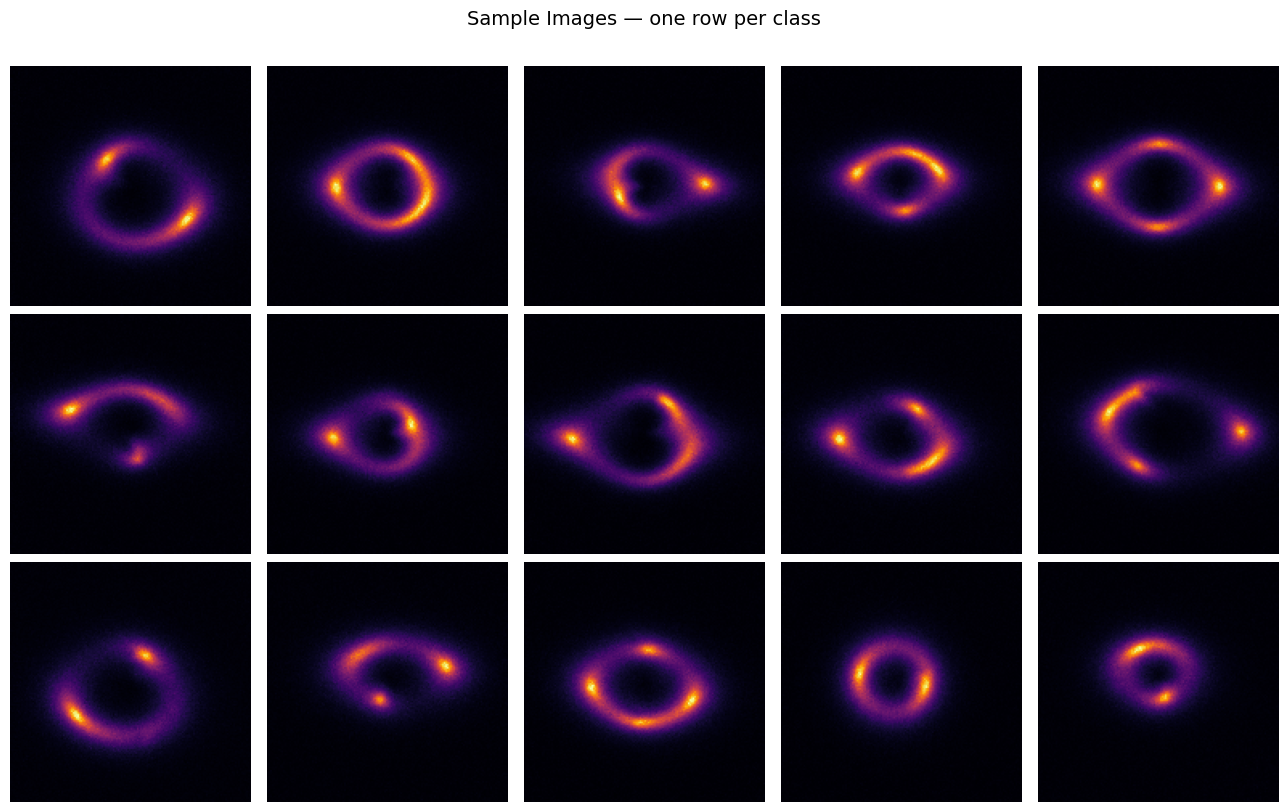

In [5]:
fig, axes = plt.subplots(3, 5, figsize=(13, 8))
fig.suptitle("Sample Images — one row per class", fontsize=14, y=1.01)

# Collect 5 samples per class from the full_train_ds
collected = {0: [], 1: [], 2: []}
for img, lbl in full_train_ds:
    if len(collected[lbl]) < 5:
        collected[lbl].append(img)
    if all(len(v) == 5 for v in collected.values()):
        break

for row, cls_idx in enumerate([0, 1, 2]):
    axes[row, 0].set_ylabel(CLASS_NAMES[cls_idx], fontsize=12, rotation=0,
                            labelpad=45, va="center")
    for col, img in enumerate(collected[cls_idx]):
        ax = axes[row, col]
        ax.imshow(img.squeeze().numpy(), cmap="inferno", origin="lower")
        ax.axis("off")

plt.tight_layout()
plt.show()

In [6]:
class CNN(nn.Module):
    """
    CNN for (1, 150, 150) gravitational lens images.

    Block 1 : Conv(1->16)   + BN + ReLU -> MaxPool -> 75x75
    Block 2 : Conv(16->32)  + BN + ReLU -> MaxPool -> 37x37
    Block 3 : Conv(32->64)  + BN + ReLU -> MaxPool -> 18x18
    Block 4 : Conv(64->128) + BN + ReLU -> MaxPool ->  9x9
    Block 5 : Conv(128->256)+ BN + ReLU
    Head    : AdaptiveAvgPool(1) -> Flatten -> Dropout
              -> FC(256->128) -> ReLU -> FC(128->3)
    """
    def __init__(self, num_classes=3, dropout=0.4):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                         # 150 -> 75

            # Block 2
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                         # 75 -> 37

            # Block 3
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                         # 37 -> 18

            # Block 4
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                         # 18 -> 9

            # Block 5
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),                 # (B, 256, 1, 1)
            nn.Flatten(),                            # (B, 256)
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout / 2),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


model = CNN(num_classes=3, dropout=DROPOUT).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model      : CNN")
print(f"Parameters : {total_params:,}")
print(f"Device     : {DEVICE}")
print()
print(model)

Model      : CNN
Parameters : 426,595
Device     : cuda

CNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1

In [7]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)  # slight smoothing helps generalisation

optimiser = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

# Warm-up for 3 epochs then cosine decay
def lr_lambda(epoch):
    warmup = 3
    if epoch < warmup:
        return (epoch + 1) / warmup
    progress = (epoch - warmup) / max(1, EPOCHS - warmup)
    return 0.5 * (1.0 + np.cos(np.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimiser, lr_lambda)

print(f"Loss       : CrossEntropyLoss (label_smoothing=0.05)")
print(f"Optimiser  : AdamW  lr={LR}  weight_decay={WEIGHT_DECAY}")
print(f"Scheduler  : 3-epoch warm-up + cosine decay over {EPOCHS} epochs")

Loss       : CrossEntropyLoss (label_smoothing=0.05)
Optimiser  : AdamW  lr=0.0003  weight_decay=0.0001
Scheduler  : 3-epoch warm-up + cosine decay over 40 epochs


In [9]:
def run_epoch(model, loader, optimiser, criterion, device, train=True):
    model.train() if train else model.eval()
    total_loss = correct = total = 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            y = (y.to(device) if isinstance(y, torch.Tensor)
                 else torch.tensor(y, dtype=torch.long, device=device))
            if train:
                optimiser.zero_grad()
            logits = model(x)
            loss   = criterion(logits, y)
            if train:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimiser.step()
            total_loss += loss.item() * len(y)
            correct    += (logits.argmax(1) == y).sum().item()
            total      += len(y)
    return total_loss / total, correct / total


# ── History storage ────────────────────────────────────────────────────────
history = {
    "epoch":    [],
    "tr_loss":  [], "tr_acc":  [],
    "val_loss": [], "val_acc": [],
    "lr":       []
}

best_val_acc = 0.0
best_state   = None
no_improve   = 0
CKPT_PATH    = "cnn_lens_best.pth"

# ── Header ────────────────────────────────────────────────────────────────
header = (f"{'Epoch':>6}  {'LR':>9}  "
          f"{'Tr Loss':>8}  {'Tr Acc':>7}  "
          f"{'Va Loss':>8}  {'Va Acc':>7}  {'':>6}")
print(header)
print("-" * len(header))

t_start = time.time()

for epoch in range(1, EPOCHS + 1):
    ep_t0 = time.time()

    tr_loss, tr_acc   = run_epoch(model, train_loader, optimiser,
                                   criterion, DEVICE, train=True)
    val_loss, val_acc = run_epoch(model, val_loader,   optimiser,
                                   criterion, DEVICE, train=False)
    current_lr = optimiser.param_groups[0]["lr"]
    scheduler.step()

    # Store history
    history["epoch"].append(epoch)
    history["tr_loss"].append(tr_loss)
    history["tr_acc"].append(tr_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["lr"].append(current_lr)

    # Checkpoint
    marker = ""
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        torch.save(best_state, CKPT_PATH)
        no_improve   = 0
        marker       = "<- best"
    else:
        no_improve  += 1

    ep_time = time.time() - ep_t0
    print(f"{epoch:>6}  {current_lr:>9.2e}  "
          f"{tr_loss:>8.4f}  {tr_acc:>7.4f}  "
          f"{val_loss:>8.4f}  {val_acc:>7.4f}  "
          f"{marker:<8}  [{ep_time:.0f}s]")

total_time = time.time() - t_start
print(f"\nTraining complete  |  Best val acc: {best_val_acc:.4f}  |  Total time: {total_time/60:.1f} min")
print(f"Best checkpoint saved to: {CKPT_PATH}")

 Epoch         LR   Tr Loss   Tr Acc   Va Loss   Va Acc        
---------------------------------------------------------------
     1   2.00e-04    1.0997   0.3411    1.0980   0.3543  <- best   [57s]
     2   3.00e-04    1.0985   0.3435    1.1026   0.3372            [57s]
     3   3.00e-04    1.0789   0.3897    1.5242   0.3423            [56s]
     4   2.99e-04    1.0067   0.4785    0.9877   0.4932  <- best   [57s]
     5   2.98e-04    0.9731   0.5080    0.9774   0.5143  <- best   [57s]
     6   2.95e-04    0.9487   0.5291    1.0154   0.4945            [57s]
     7   2.91e-04    0.9258   0.5443    1.1628   0.4635            [58s]
     8   2.87e-04    0.8908   0.5764    0.8870   0.5995  <- best   [57s]
     9   2.81e-04    0.8410   0.6235    0.9258   0.5548            [57s]
    10   2.74e-04    0.8001   0.6567    0.8404   0.6284  <- best   [57s]
    11   2.67e-04    0.7647   0.6830    0.7957   0.6600  <- best   [56s]
    12   2.58e-04    0.7339   0.7046    0.7439   0.6963  <- best   [5

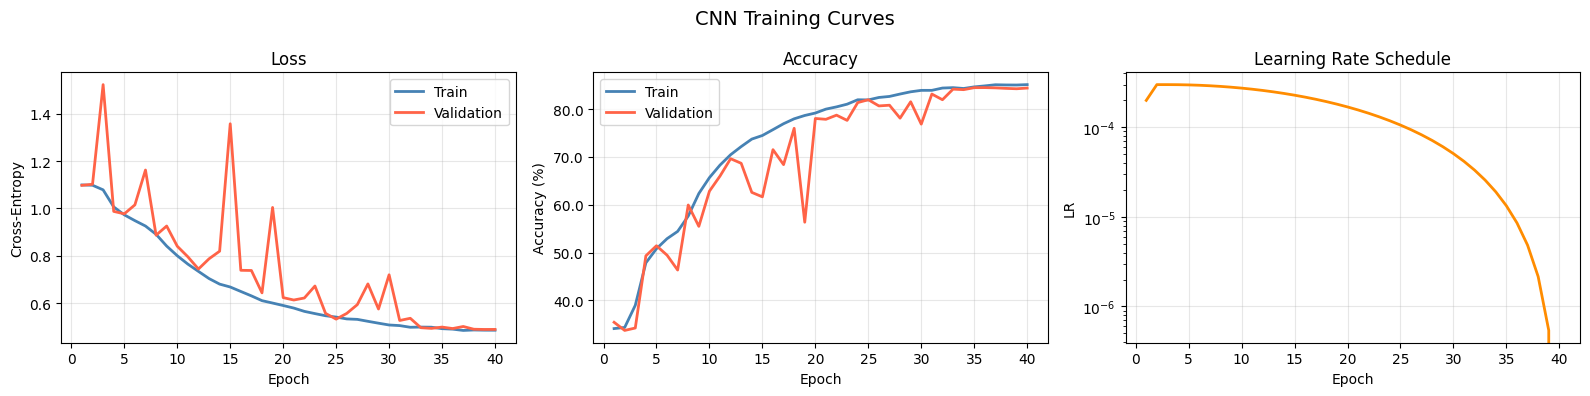

Saved: training_curves.png


In [10]:
epochs_x = history["epoch"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("CNN Training Curves", fontsize=14)

# Loss
ax = axes[0]
ax.plot(epochs_x, history["tr_loss"],  label="Train",      color="steelblue",  lw=2)
ax.plot(epochs_x, history["val_loss"], label="Validation", color="tomato",     lw=2)
ax.set_title("Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-Entropy")
ax.legend()
ax.grid(alpha=0.3)

# Accuracy
ax = axes[1]
ax.plot(epochs_x, [v*100 for v in history["tr_acc"]],  label="Train",      color="steelblue",  lw=2)
ax.plot(epochs_x, [v*100 for v in history["val_acc"]], label="Validation", color="tomato",     lw=2)
ax.set_title("Accuracy")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy (%)")
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
ax.legend()
ax.grid(alpha=0.3)

# Learning rate
ax = axes[2]
ax.plot(epochs_x, history["lr"], color="darkorange", lw=2)
ax.set_title("Learning Rate Schedule")
ax.set_xlabel("Epoch")
ax.set_ylabel("LR")
ax.set_yscale("log")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: training_curves.png")

In [11]:
# Load best checkpoint
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model.eval()

all_preds  = []
all_labels = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(DEVICE)
        y = (y if isinstance(y, torch.Tensor)
             else torch.tensor(y, dtype=torch.long))
        preds = model(x).argmax(1).cpu()
        all_preds.extend(preds.tolist())
        all_labels.extend(y.tolist())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

test_acc = (all_preds == all_labels).mean()
print(f"Test Accuracy (10% held-out): {test_acc:.4f}  ({test_acc*100:.2f}%)")
print()
print(classification_report(all_labels, all_preds,
                             target_names=CLASS_NAMES, digits=4))

C:\Users\Sumit Sharma\AppData\Local\Temp\ipykernel_14960\2457249563.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(CKPT_PATH, map_locat

Test Accuracy (10% held-out): 0.8470  (84.70%)

              precision    recall  f1-score   support

          no     0.8041    0.9604    0.8753      1009
        vort     0.8754    0.8159    0.8446      1059
      sphere     0.8762    0.7597    0.8138       932

    accuracy                         0.8470      3000
   macro avg     0.8519    0.8453    0.8446      3000
weighted avg     0.8517    0.8470    0.8454      3000



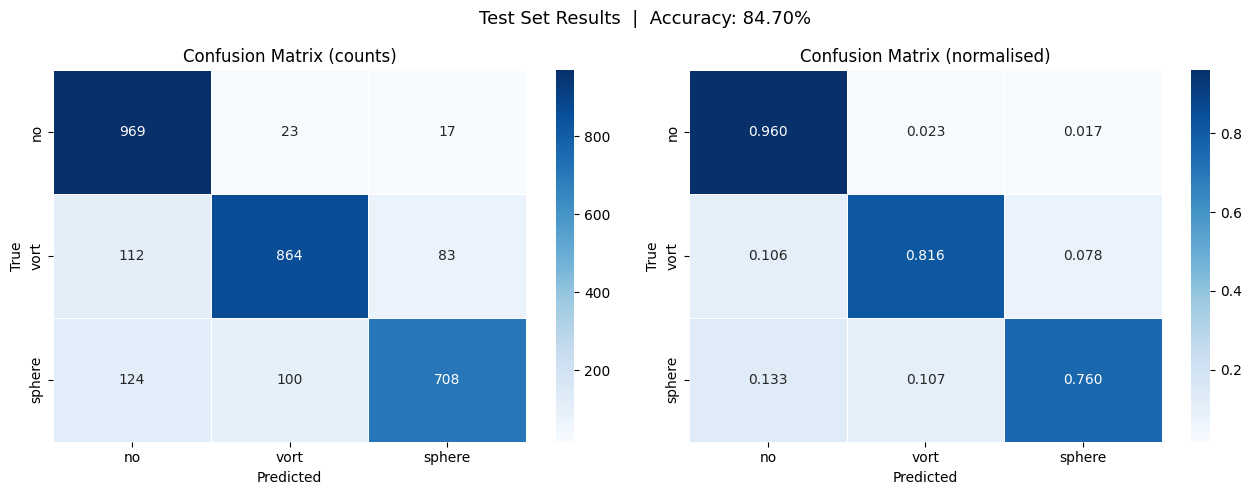

Saved: confusion_matrix.png


In [12]:
cm = confusion_matrix(all_labels, all_preds)

# Normalised (per-true-class)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, data, fmt, title in [
    (axes[0], cm,      "d",    "Confusion Matrix (counts)"),
    (axes[1], cm_norm, ".3f",  "Confusion Matrix (normalised)"),
]:
    sns.heatmap(data, annot=True, fmt=fmt, cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=ax, linewidths=0.5)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.suptitle(f"Test Set Results  |  Accuracy: {test_acc*100:.2f}%", fontsize=13)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: confusion_matrix.png")

In [13]:
print(f"{'Class':<10}  {'Correct':>8}  {'Total':>8}  {'Accuracy':>10}")
print("-" * 42)
for cls_idx, name in enumerate(CLASS_NAMES):
    mask    = all_labels == cls_idx
    correct = (all_preds[mask] == cls_idx).sum()
    total   = mask.sum()
    acc     = correct / total if total > 0 else 0.0
    print(f"{name:<10}  {correct:>8}  {total:>8}  {acc:>10.4f}")

print("-" * 42)
print(f"{'Overall':<10}  {(all_preds==all_labels).sum():>8}  "
      f"{len(all_labels):>8}  {test_acc:>10.4f}")

Class        Correct     Total    Accuracy
------------------------------------------
no               969      1009      0.9604
vort             864      1059      0.8159
sphere           708       932      0.7597
------------------------------------------
Overall         2541      3000      0.8470


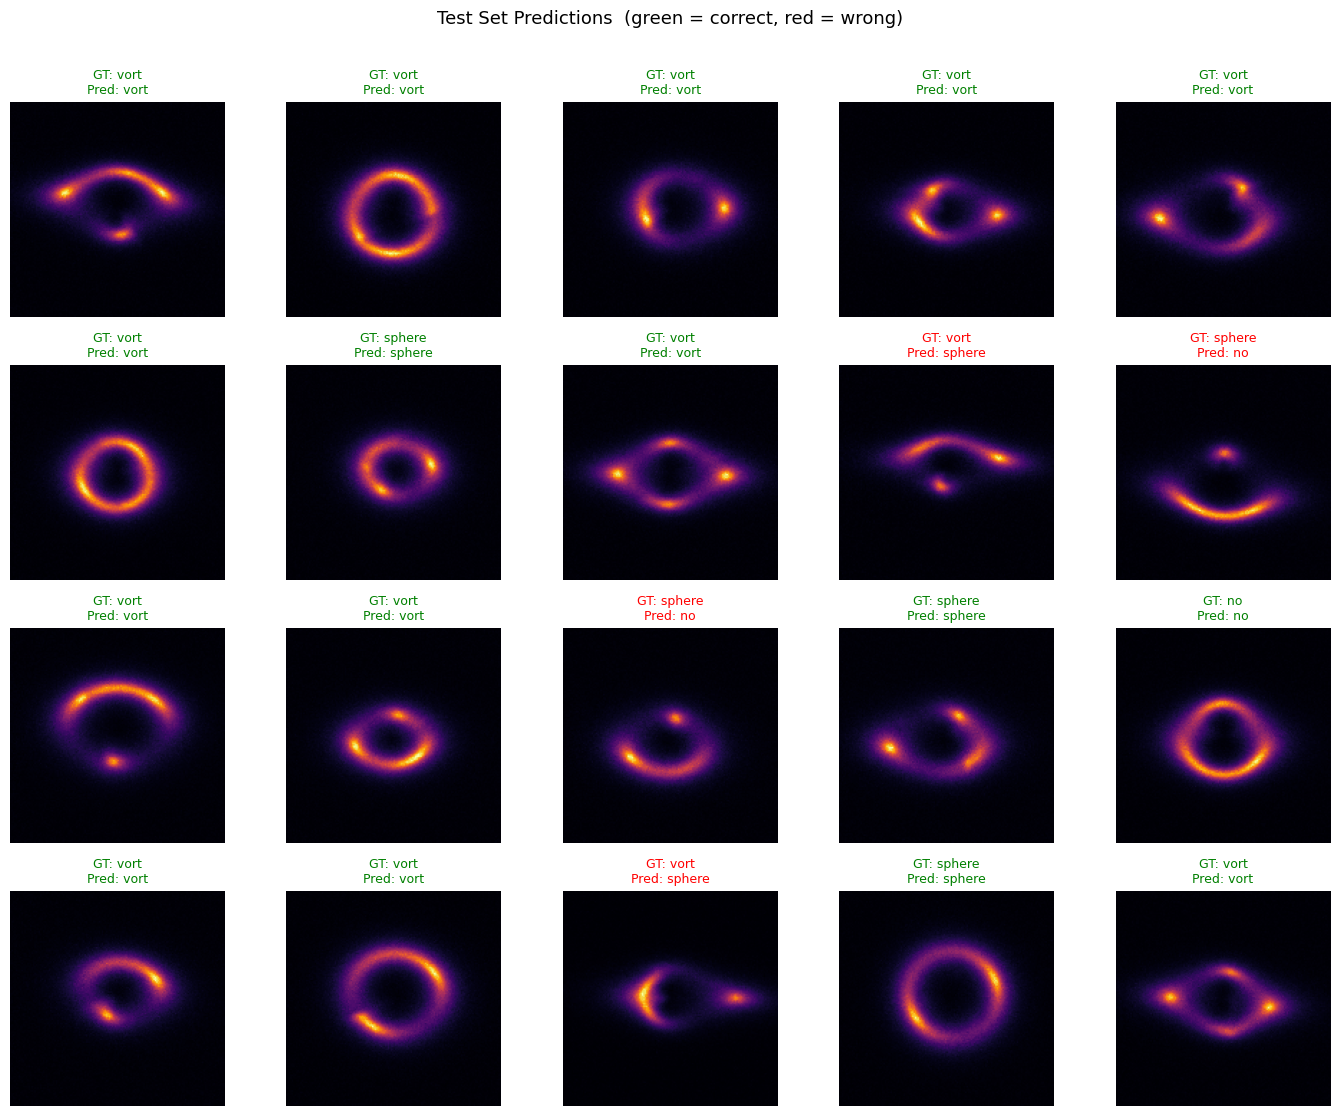

Saved: predictions.png


In [14]:
model.eval()
samples, gt_labels, pred_labels = [], [], []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(DEVICE)
        preds = model(x).argmax(1).cpu()
        y = y if isinstance(y, torch.Tensor) else torch.tensor(y)
        for img, gt, pr in zip(x.cpu(), y, preds):
            samples.append(img)
            gt_labels.append(gt.item())
            pred_labels.append(pr.item())
        if len(samples) >= 20:
            break

fig, axes = plt.subplots(4, 5, figsize=(14, 11))
fig.suptitle("Test Set Predictions  (green = correct, red = wrong)",
             fontsize=13, y=1.01)

for i, ax in enumerate(axes.flat):
    img  = samples[i].squeeze().numpy()
    gt   = CLASS_NAMES[gt_labels[i]]
    pred = CLASS_NAMES[pred_labels[i]]
    correct = gt_labels[i] == pred_labels[i]

    ax.imshow(img, cmap="inferno", origin="lower")
    ax.set_title(f"GT: {gt}\nPred: {pred}",
                 fontsize=9,
                 color="green" if correct else "red")
    ax.axis("off")

    # Border colour
    for spine in ax.spines.values():
        spine.set_edgecolor("green" if correct else "red")
        spine.set_linewidth(2)
        spine.set_visible(True)

plt.tight_layout()
plt.savefig("predictions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: predictions.png")

In [15]:
best_ep  = history["val_acc"].index(max(history["val_acc"])) + 1
best_val = max(history["val_acc"])

print("=" * 50)
print("  CNN LENS CLASSIFIER — FINAL RESULTS")
print("=" * 50)
print(f"  Total samples loaded : {len(full_train_ds) + len(val_ds):,}")
print(f"  Training samples     : {len(train_ds_aug):,}  (90%)")
print(f"  Test samples         : {len(test_ds):,}  (10%)")
print(f"  Validation samples   : {len(val_ds):,}  (val/ folder)")
print(f"  Model parameters     : {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"  Epochs trained       : {len(history['epoch'])}")
print(f"  Best epoch           : {best_ep}  (val acc = {best_val:.4f})")
print(f"  Test accuracy        : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print("=" * 50)
print(f"  Checkpoint : {CKPT_PATH}")
print("=" * 50)

  CNN LENS CLASSIFIER — FINAL RESULTS
  Total samples loaded : 37,500
  Training samples     : 27,000  (90%)
  Test samples         : 3,000  (10%)
  Validation samples   : 7,500  (val/ folder)
  Model parameters     : 426,595
  Epochs trained       : 40
  Best epoch           : 36  (val acc = 0.8449)
  Test accuracy        : 0.8470  (84.70%)
  Checkpoint : cnn_lens_best.pth


In [17]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# ── Collect raw softmax probabilities and true labels ─────────────────────
# Make sure model is in eval mode and best checkpoint is loaded
model.eval()

all_probs  = []   # softmax probability vectors  shape: (N, 3)
all_labels = []   # integer ground truth labels  shape: (N,)

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(DEVICE)
        logits = model(x)                          # (B, 3)
        probs  = F.softmax(logits, dim=1).cpu()    # (B, 3)  probabilities
        y      = y if isinstance(y, torch.Tensor) else torch.tensor(y)
        all_probs.append(probs.numpy())
        all_labels.append(y.numpy())

all_probs  = np.concatenate(all_probs,  axis=0)   # (N, 3)
all_labels = np.concatenate(all_labels, axis=0)   # (N,)

# Binarise labels for OvR ROC  →  shape (N, 3)
n_classes      = len(CLASS_NAMES)
labels_bin     = label_binarize(all_labels, classes=list(range(n_classes)))

print(f"Test samples      : {len(all_labels):,}")
print(f"Probability array : {all_probs.shape}")
print(f"Binarised labels  : {labels_bin.shape}")
print()
print(f"Class distribution in test set:")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name:<8} : {(all_labels == i).sum():>5} samples")

Test samples      : 3,000
Probability array : (3000, 3)
Binarised labels  : (3000, 3)

Class distribution in test set:
  no       :  1009 samples
  vort     :  1059 samples
  sphere   :   932 samples


In [18]:
# ── Per-class ROC (One-vs-Rest) ────────────────────────────────────────────
fpr       = {}   # false positive rate arrays
tpr       = {}   # true  positive rate arrays
roc_auc   = {}   # scalar AUC per class

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(labels_bin[:, i], all_probs[:, i])
    roc_auc[i]        = auc(fpr[i], tpr[i])

# ── Micro-average ROC (treats every sample-class pair equally) ─────────────
fpr["micro"], tpr["micro"], _ = roc_curve(
    labels_bin.ravel(), all_probs.ravel()
)
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# ── Macro-average ROC (interpolated mean over per-class curves) ────────────
all_fpr        = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr       = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr  += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr      /= n_classes
fpr["macro"]   = all_fpr
tpr["macro"]   = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# ── Print AUC table ────────────────────────────────────────────────────────
print("AUC Scores (Area Under the ROC Curve)")
print("=" * 40)
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name:<10} (OvR)   : {roc_auc[i]:.4f}")
print("-" * 40)
print(f"  {'Micro-avg':<16}  : {roc_auc['micro']:.4f}")
print(f"  {'Macro-avg':<16}  : {roc_auc['macro']:.4f}")
print("=" * 40)

AUC Scores (Area Under the ROC Curve)
  no         (OvR)   : 0.9717
  vort       (OvR)   : 0.9534
  sphere     (OvR)   : 0.9348
----------------------------------------
  Micro-avg         : 0.9570
  Macro-avg         : 0.9535


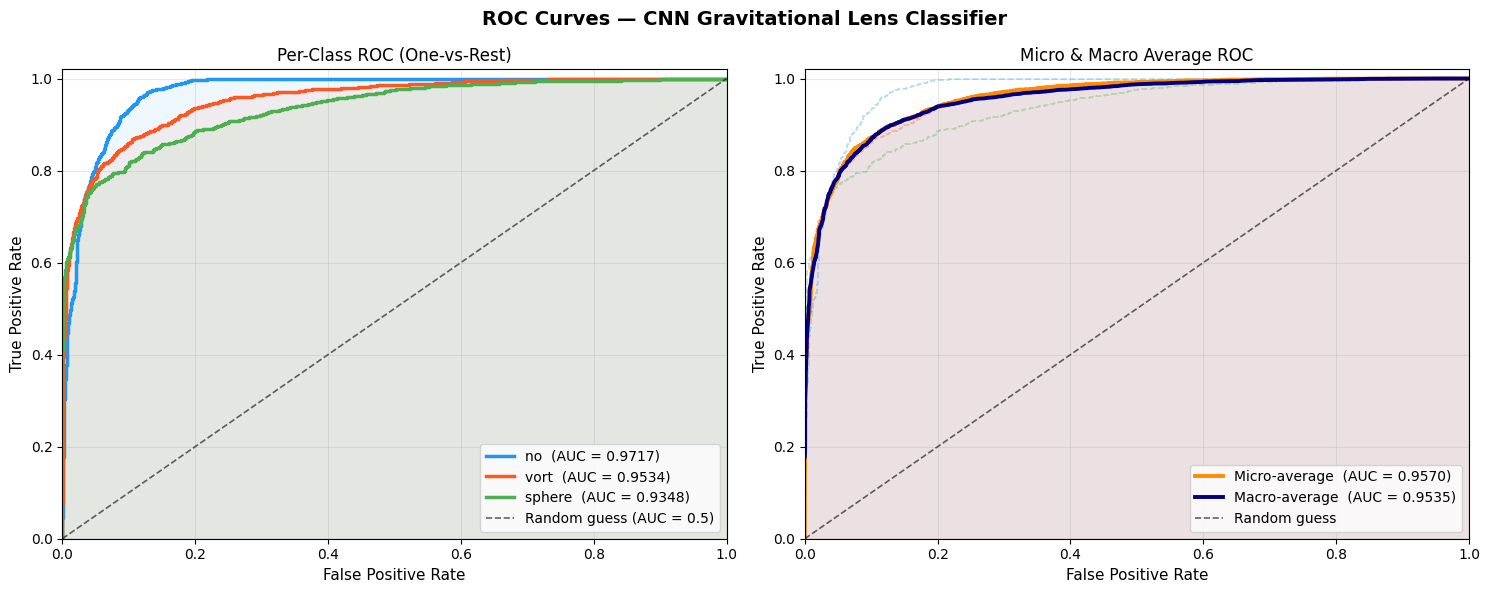

Saved: roc_curves.png


In [19]:
# Colour palette for the 3 classes
CLASS_COLORS = ["#2196F3", "#FF5722", "#4CAF50"]   # blue, deep-orange, green

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("ROC Curves — CNN Gravitational Lens Classifier",
             fontsize=14, fontweight="bold")

# ── LEFT: Per-class OvR curves ─────────────────────────────────────────────
ax = axes[0]
for i, name in enumerate(CLASS_NAMES):
    ax.plot(
        fpr[i], tpr[i],
        color=CLASS_COLORS[i],
        lw=2.5,
        label=f"{name}  (AUC = {roc_auc[i]:.4f})"
    )

# Random-guess baseline
ax.plot([0, 1], [0, 1], "k--", lw=1.2, alpha=0.6, label="Random guess (AUC = 0.5)")

ax.set_title("Per-Class ROC (One-vs-Rest)", fontsize=12)
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.legend(loc="lower right", fontsize=10)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.02])
ax.grid(alpha=0.3)

# Shade area under each curve
for i in range(n_classes):
    ax.fill_between(fpr[i], tpr[i], alpha=0.07, color=CLASS_COLORS[i])

# ── RIGHT: Micro + Macro average curves ───────────────────────────────────
ax = axes[1]

# Faint per-class lines for reference
for i, name in enumerate(CLASS_NAMES):
    ax.plot(fpr[i], tpr[i],
            color=CLASS_COLORS[i], lw=1.2, alpha=0.35, linestyle="--")

ax.plot(
    fpr["micro"], tpr["micro"],
    color="darkorange", lw=2.8, linestyle="-",
    label=f"Micro-average  (AUC = {roc_auc['micro']:.4f})"
)
ax.plot(
    fpr["macro"], tpr["macro"],
    color="navy", lw=2.8, linestyle="-",
    label=f"Macro-average  (AUC = {roc_auc['macro']:.4f})"
)
ax.plot([0, 1], [0, 1], "k--", lw=1.2, alpha=0.6, label="Random guess")

ax.fill_between(fpr["micro"], tpr["micro"], alpha=0.08, color="darkorange")
ax.fill_between(fpr["macro"], tpr["macro"], alpha=0.08, color="navy")

ax.set_title("Micro & Macro Average ROC", fontsize=12)
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.legend(loc="lower right", fontsize=10)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.02])
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: roc_curves.png")

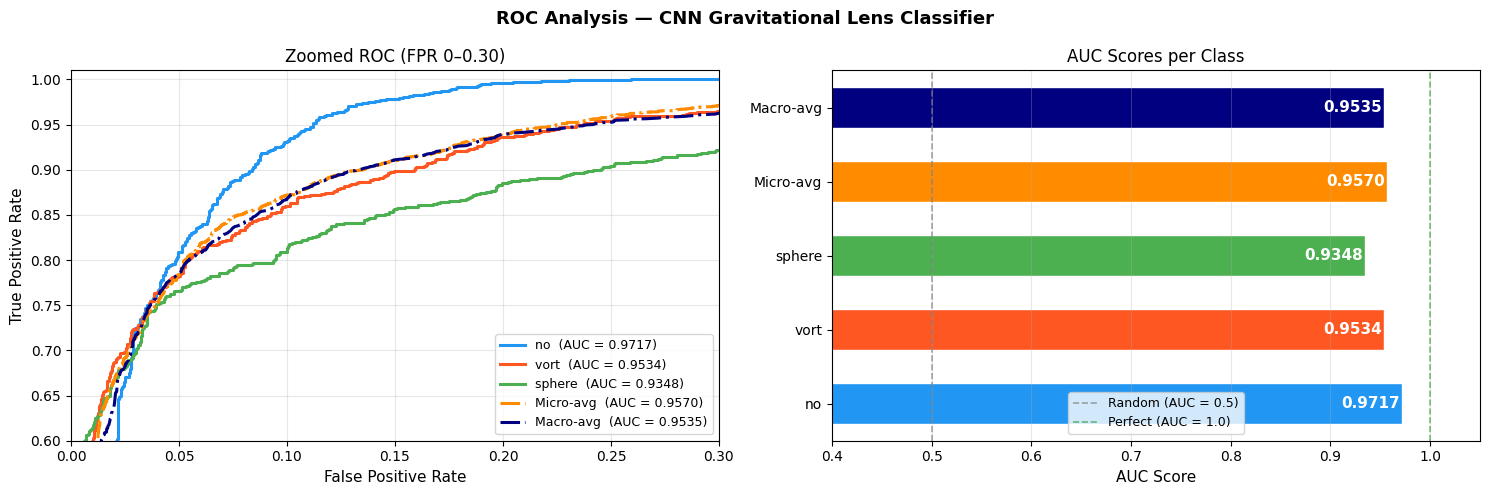

Saved: roc_zoomed_and_auc_bar.png


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── LEFT: Zoomed ROC 0–0.3 FPR region ─────────────────────────────────────
ax = axes[0]
for i, name in enumerate(CLASS_NAMES):
    ax.plot(fpr[i], tpr[i], color=CLASS_COLORS[i], lw=2.2,
            label=f"{name}  (AUC = {roc_auc[i]:.4f})")
ax.plot(fpr["micro"], tpr["micro"], color="darkorange", lw=2.2, linestyle="-.",
        label=f"Micro-avg  (AUC = {roc_auc['micro']:.4f})")
ax.plot(fpr["macro"], tpr["macro"], color="navy",      lw=2.2, linestyle="-.",
        label=f"Macro-avg  (AUC = {roc_auc['macro']:.4f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)

ax.set_xlim([0.0, 0.30])   # zoom into the critical low-FPR region
ax.set_ylim([0.60, 1.01])
ax.set_title("Zoomed ROC (FPR 0–0.30)", fontsize=12)
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.legend(loc="lower right", fontsize=9)
ax.grid(alpha=0.3)

# ── RIGHT: AUC bar chart ───────────────────────────────────────────────────
ax = axes[1]

bar_labels = CLASS_NAMES + ["Micro-avg", "Macro-avg"]
bar_values = [roc_auc[i] for i in range(n_classes)] + \
             [roc_auc["micro"], roc_auc["macro"]]
bar_colors = CLASS_COLORS + ["darkorange", "navy"]

bars = ax.barh(bar_labels, bar_values, color=bar_colors,
               edgecolor="white", height=0.55)

# Annotate values on bars
for bar, val in zip(bars, bar_values):
    ax.text(
        bar.get_width() - 0.002, bar.get_y() + bar.get_height() / 2,
        f"{val:.4f}",
        va="center", ha="right",
        fontsize=11, fontweight="bold", color="white"
    )

# Reference line at AUC = 0.5
ax.axvline(0.5, color="gray", linestyle="--", lw=1.2, alpha=0.7,
           label="Random (AUC = 0.5)")
ax.axvline(1.0, color="green", linestyle="--", lw=1.2, alpha=0.5,
           label="Perfect (AUC = 1.0)")

ax.set_xlim([0.4, 1.05])
ax.set_xlabel("AUC Score", fontsize=11)
ax.set_title("AUC Scores per Class", fontsize=12)
ax.legend(fontsize=9)
ax.grid(axis="x", alpha=0.3)

plt.suptitle("ROC Analysis — CNN Gravitational Lens Classifier",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("roc_zoomed_and_auc_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: roc_zoomed_and_auc_bar.png")

In [21]:
from sklearn.metrics import roc_auc_score

# sklearn's roc_auc_score with OvR and OvO strategies
auc_ovr_macro  = roc_auc_score(all_labels, all_probs, multi_class="ovr",  average="macro")
auc_ovr_weighted = roc_auc_score(all_labels, all_probs, multi_class="ovr", average="weighted")
auc_ovo_macro  = roc_auc_score(all_labels, all_probs, multi_class="ovo",  average="macro")
auc_ovo_weighted = roc_auc_score(all_labels, all_probs, multi_class="ovo", average="weighted")

print("=" * 55)
print("  COMPLETE AUC SUMMARY")
print("=" * 55)
print()
print("  Per-class AUC (One-vs-Rest):")
print(f"  {'Class':<12}  {'AUC':>8}  {'Interpretation'}")
print("  " + "-" * 48)
for i, name in enumerate(CLASS_NAMES):
    a = roc_auc[i]
    if   a >= 0.95: interp = "Excellent"
    elif a >= 0.90: interp = "Very good"
    elif a >= 0.80: interp = "Good"
    elif a >= 0.70: interp = "Fair"
    else:           interp = "Poor"
    print(f"  {name:<12}  {a:>8.4f}  {interp}")

print()
print("  Aggregate AUC:")
print(f"  {'Micro-average':<22}  {roc_auc['micro']:.4f}")
print(f"  {'Macro-average':<22}  {roc_auc['macro']:.4f}")
print()
print("  sklearn roc_auc_score:")
print(f"  {'OvR  macro':<22}  {auc_ovr_macro:.4f}")
print(f"  {'OvR  weighted':<22}  {auc_ovr_weighted:.4f}")
print(f"  {'OvO  macro':<22}  {auc_ovo_macro:.4f}")
print(f"  {'OvO  weighted':<22}  {auc_ovo_weighted:.4f}")
print("=" * 55)
print()
print("  Note:")
print("  OvR = One-vs-Rest  |  OvO = One-vs-One")
print("  AUC = 1.0 → perfect  |  AUC = 0.5 → random guess")
print("  Weighted average accounts for class imbalance.")

  COMPLETE AUC SUMMARY

  Per-class AUC (One-vs-Rest):
  Class              AUC  Interpretation
  ------------------------------------------------
  no              0.9717  Excellent
  vort            0.9534  Excellent
  sphere          0.9348  Very good

  Aggregate AUC:
  Micro-average           0.9570
  Macro-average           0.9535

  sklearn roc_auc_score:
  OvR  macro              0.9533
  OvR  weighted           0.9538
  OvO  macro              0.9530
  OvO  weighted           0.9533

  Note:
  OvR = One-vs-Rest  |  OvO = One-vs-One
  AUC = 1.0 → perfect  |  AUC = 0.5 → random guess
  Weighted average accounts for class imbalance.
